# CleanAir AI — Notebook 06: Evaluation, Ablation, and Final Packaging

This notebook performs the final evaluation and packaging for the CleanAir AI project.

## Inputs

- `reports/notebook_01_run_summary.json`
- `reports/notebook_02_run_summary.json`
- `reports/notebook_03_run_summary.json`
- `outputs/final_aqi_model_metrics.json`
- `reports/notebook_05_run_summary.json`
- `outputs/aqi_model_comparison.csv`
- `outputs/feature_importance.csv`
- `data/processed/station_aqi_history.csv`
- `data/processed/station_source_attributed.csv`
- `data/processed/station_advanced_intelligence.csv`
- `data/processed/city_advanced_intelligence_summary.csv`

## Main tasks

1. Load all notebook summaries and final outputs.
2. Perform final model evaluation review.
3. Run ablation experiments.
4. Create project-level final summary.
5. Create model card.
6. Create data dictionary.
7. Create final deliverable checklist.
8. Save all final packaging files.

In [1]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
DOCS_DIR = PROJECT_ROOT / "docs"

for folder in [
    PROCESSED_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
    MODELS_DIR,
    DOCS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Lenovo\Desktop\CleanAir_AI


In [3]:
def load_json_if_exists(path):
    path = Path(path)

    if path.exists():
        with open(path, "r", encoding="utf-8") as file:
            return json.load(file)

    return {}


def save_json(data, path):
    path = Path(path)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4)

    print("Saved:", path)


def get_aqi_category(aqi):
    if pd.isna(aqi):
        return "Unknown"

    aqi = float(aqi)

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


def rmse_manual(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


print("Helper functions ready.")

Helper functions ready.


In [4]:
notebook_01_summary = load_json_if_exists(
    REPORTS_DIR / "notebook_01_run_summary.json"
)

notebook_02_summary = load_json_if_exists(
    REPORTS_DIR / "notebook_02_run_summary.json"
)

notebook_03_summary = load_json_if_exists(
    REPORTS_DIR / "notebook_03_run_summary.json"
)

notebook_04_metrics = load_json_if_exists(
    OUTPUTS_DIR / "final_aqi_model_metrics.json"
)

notebook_05_summary = load_json_if_exists(
    REPORTS_DIR / "notebook_05_run_summary.json"
)

print("Notebook summaries loaded.")

print("Notebook 01 rows:", notebook_01_summary.get("station_level_records"))
print("Notebook 04 best model:", notebook_04_metrics.get("best_model"))
print("Notebook 05 station rows:", notebook_05_summary.get("station_rows"))

Notebook summaries loaded.
Notebook 01 rows: 500
Notebook 04 best model: Random Forest
Notebook 05 station rows: 500


In [5]:
MODEL_COMPARISON_PATH = OUTPUTS_DIR / "aqi_model_comparison.csv"
FEATURE_IMPORTANCE_PATH = OUTPUTS_DIR / "feature_importance.csv"
STATION_ADVANCED_PATH = PROCESSED_DIR / "station_advanced_intelligence.csv"
CITY_ADVANCED_PATH = PROCESSED_DIR / "city_advanced_intelligence_summary.csv"
HISTORY_PATH = PROCESSED_DIR / "station_aqi_history.csv"
SOURCE_ATTRIBUTED_PATH = PROCESSED_DIR / "station_source_attributed.csv"

required_input_files = [
    MODEL_COMPARISON_PATH,
    FEATURE_IMPORTANCE_PATH,
    STATION_ADVANCED_PATH,
    CITY_ADVANCED_PATH,
    HISTORY_PATH,
    SOURCE_ATTRIBUTED_PATH
]

for path in required_input_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

model_comparison_df = pd.read_csv(MODEL_COMPARISON_PATH)
feature_importance_df = pd.read_csv(FEATURE_IMPORTANCE_PATH)
station_advanced_df = pd.read_csv(STATION_ADVANCED_PATH)
city_advanced_df = pd.read_csv(CITY_ADVANCED_PATH)
history_df = pd.read_csv(HISTORY_PATH)
source_df = pd.read_csv(SOURCE_ATTRIBUTED_PATH)

print("Loaded final output tables.")
print("Model comparison:", model_comparison_df.shape)
print("Feature importance:", feature_importance_df.shape)
print("Station advanced:", station_advanced_df.shape)
print("City advanced:", city_advanced_df.shape)
print("History:", history_df.shape)
print("Source attributed:", source_df.shape)

Loaded final output tables.
Model comparison: (8, 5)
Feature importance: (358, 2)
Station advanced: (500, 81)
City advanced: (266, 16)
History: (6072, 25)
Source attributed: (500, 50)


In [6]:
best_model_name = notebook_04_metrics.get("best_model")
best_metrics = notebook_04_metrics.get("best_metrics", {})

final_model_review = {
    "best_model": best_model_name,
    "mae": best_metrics.get("mae"),
    "rmse": best_metrics.get("rmse"),
    "r2": best_metrics.get("r2"),
    "improvement_over_persistence_percent": best_metrics.get(
        "improvement_over_persistence_percent"
    ),
    "category_accuracy": notebook_04_metrics.get("category_accuracy"),
    "high_aqi_precision": notebook_04_metrics.get("high_aqi_precision"),
    "high_aqi_recall": notebook_04_metrics.get("high_aqi_recall"),
    "high_aqi_f1": notebook_04_metrics.get("high_aqi_f1"),
    "unique_timestamps": notebook_04_metrics.get("unique_timestamps"),
    "train_rows": notebook_04_metrics.get("train_rows"),
    "test_rows": notebook_04_metrics.get("test_rows")
}

final_model_review_df = pd.DataFrame([final_model_review])

FINAL_MODEL_REVIEW_PATH = OUTPUTS_DIR / "final_model_review.csv"

final_model_review_df.to_csv(FINAL_MODEL_REVIEW_PATH, index=False)

print("Final model review saved:")
print(FINAL_MODEL_REVIEW_PATH)

display(final_model_review_df)

Final model review saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\final_model_review.csv


,best_model,mae,rmse,r2,improvement_over_persistence_percent,category_accuracy,high_aqi_precision,high_aqi_recall,high_aqi_f1,unique_timestamps,train_rows,test_rows
0,Random Forest,14.5002,39.879,0.8718,4.22,0.8905,0.9634,0.9922,0.9776,12,4124,1032


In [7]:
history_df["timestamp"] = pd.to_datetime(
    history_df["timestamp"],
    errors="coerce"
)

history_df["reported_aqi"] = pd.to_numeric(
    history_df["reported_aqi"],
    errors="coerce"
)

history_df = history_df.dropna(
    subset=["station_id", "timestamp", "reported_aqi"]
).copy()

history_df = history_df.sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)

context_columns = [
    "station_id",
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "wind_speed_10m",
    "cloud_cover",
    "weather_trapping_score",
    "urban_pressure_score",
    "road_density_proxy",
    "environmental_risk_score",
    "primary_pollution_source",
    "source_attribution_confidence_category",
    "landuse_type_proxy"
]

available_context_columns = [
    col for col in context_columns
    if col in source_df.columns
]

context_df = source_df[available_context_columns].drop_duplicates(
    subset=["station_id"]
)

ablation_df = history_df.merge(
    context_df,
    on="station_id",
    how="left"
)

ablation_df = ablation_df.sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)

ablation_df["target_aqi_next"] = (
    ablation_df
    .groupby("station_id")["reported_aqi"]
    .shift(-1)
)

ablation_df = ablation_df.dropna(
    subset=["target_aqi_next"]
).copy()

print("Ablation base data prepared.")
print("Shape:", ablation_df.shape)
print("Unique timestamps:", ablation_df["timestamp"].nunique())

Ablation base data prepared.
Shape: (5156, 38)
Unique timestamps: 11


In [8]:
for lag in [1, 2, 3, 6, 12]:
    ablation_df[f"aqi_lag_{lag}"] = (
        ablation_df
        .groupby("station_id")["reported_aqi"]
        .shift(lag)
    )

for window in [3, 6, 12]:
    ablation_df[f"aqi_rolling_mean_{window}"] = (
        ablation_df
        .groupby("station_id")["reported_aqi"]
        .transform(
            lambda s: s.shift(1).rolling(
                window=window,
                min_periods=1
            ).mean()
        )
    )

    ablation_df[f"aqi_rolling_std_{window}"] = (
        ablation_df
        .groupby("station_id")["reported_aqi"]
        .transform(
            lambda s: s.shift(1).rolling(
                window=window,
                min_periods=2
            ).std()
        )
    )

ablation_df["hour"] = ablation_df["timestamp"].dt.hour
ablation_df["dayofweek"] = ablation_df["timestamp"].dt.dayofweek
ablation_df["month"] = ablation_df["timestamp"].dt.month
ablation_df["is_weekend"] = ablation_df["dayofweek"].isin([5, 6]).astype(int)

ablation_df["station_expanding_mean_aqi"] = (
    ablation_df
    .groupby("station_id")["reported_aqi"]
    .transform(lambda s: s.shift(1).expanding().mean())
)

ablation_df["station_expanding_std_aqi"] = (
    ablation_df
    .groupby("station_id")["reported_aqi"]
    .transform(lambda s: s.shift(1).expanding().std())
)

print("Ablation features created.")

Ablation features created.


In [9]:
lag_features = [
    col for col in ablation_df.columns
    if col.startswith("aqi_lag_")
    or col.startswith("aqi_rolling_")
    or col in [
        "station_expanding_mean_aqi",
        "station_expanding_std_aqi"
    ]
]

time_features = [
    "hour",
    "dayofweek",
    "month",
    "is_weekend"
]

weather_features = [
    col for col in [
        "temperature_2m",
        "relative_humidity_2m",
        "rain",
        "wind_speed_10m",
        "cloud_cover",
        "weather_trapping_score"
    ]
    if col in ablation_df.columns
]

geospatial_risk_features = [
    col for col in [
        "urban_pressure_score",
        "road_density_proxy",
        "environmental_risk_score"
    ]
    if col in ablation_df.columns
]

categorical_features = [
    col for col in [
        "state",
        "city",
        "reported_aqi_category",
        "reported_dominant_pollutant",
        "primary_pollution_source",
        "source_attribution_confidence_category",
        "landuse_type_proxy"
    ]
    if col in ablation_df.columns
]

print("Lag features:", len(lag_features))
print("Time features:", len(time_features))
print("Weather features:", len(weather_features))
print("Geospatial/risk features:", len(geospatial_risk_features))
print("Categorical features:", len(categorical_features))

Lag features: 13
Time features: 4
Weather features: 6
Geospatial/risk features: 3
Categorical features: 7


In [12]:
def run_ablation_experiment(experiment_name, selected_features):
    selected_features = [
        col for col in selected_features
        if col in ablation_df.columns
        and col not in [
            "timestamp",
            "target_aqi_next"
        ]
    ]

    # Remove duplicate features while preserving order
    selected_features = list(dict.fromkeys(selected_features))

    required_columns = [
        "timestamp",
        "target_aqi_next"
    ]

    # Add reported_aqi only if it is not already included
    if "reported_aqi" not in selected_features:
        selected_features = ["reported_aqi"] + selected_features

    experiment_columns = selected_features + required_columns

    # Remove duplicate columns again for safety
    experiment_columns = list(dict.fromkeys(experiment_columns))

    experiment_df = ablation_df[experiment_columns].copy()

    categorical_selected = [
        col for col in selected_features
        if col in categorical_features
    ]

    if categorical_selected:
        experiment_df = pd.get_dummies(
            experiment_df,
            columns=categorical_selected,
            drop_first=False
        )

    feature_cols = [
        col for col in experiment_df.columns
        if col not in [
            "timestamp",
            "target_aqi_next"
        ]
        and pd.api.types.is_numeric_dtype(experiment_df[col])
    ]

    experiment_df = experiment_df.sort_values("timestamp").reset_index(drop=True)

    split_index = int(len(experiment_df) * 0.8)

    train_df = experiment_df.iloc[:split_index].copy()
    test_df = experiment_df.iloc[split_index:].copy()

    X_train = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_test = test_df[feature_cols].replace([np.inf, -np.inf], np.nan)

    train_medians = X_train.median(numeric_only=True)

    X_train = X_train.fillna(train_medians).fillna(0)
    X_test = X_test.fillna(train_medians).fillna(0)

    y_train = pd.to_numeric(
        train_df["target_aqi_next"],
        errors="coerce"
    ).to_numpy().reshape(-1)

    y_test = pd.to_numeric(
        test_df["target_aqi_next"],
        errors="coerce"
    ).to_numpy().reshape(-1)

    if experiment_name == "Persistence Baseline":
        predictions = pd.to_numeric(
            test_df["reported_aqi"],
            errors="coerce"
        ).to_numpy().reshape(-1)

        model_type = "Baseline"

    else:
        model = RandomForestRegressor(
            n_estimators=150,
            max_depth=14,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_train, y_train)
        predictions = model.predict(X_test).reshape(-1)

        model_type = "RandomForestRegressor"

    if len(y_test) != len(predictions):
        raise ValueError(
            f"Length mismatch: y_test={len(y_test)}, predictions={len(predictions)}"
        )

    mae = mean_absolute_error(y_test, predictions)
    rmse = rmse_manual(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return {
        "experiment": experiment_name,
        "model_type": model_type,
        "feature_count": len(feature_cols),
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        "mae": round(float(mae), 4),
        "rmse": round(float(rmse), 4),
        "r2": round(float(r2), 4)
    }


print("Ablation function ready.")

Ablation function ready.


In [13]:
ablation_results = []

ablation_results.append(
    run_ablation_experiment(
        "Persistence Baseline",
        ["reported_aqi"]
    )
)

ablation_results.append(
    run_ablation_experiment(
        "Lag Features Only",
        ["reported_aqi"] + lag_features
    )
)

ablation_results.append(
    run_ablation_experiment(
        "Lag + Time Features",
        ["reported_aqi"] + lag_features + time_features
    )
)

ablation_results.append(
    run_ablation_experiment(
        "Lag + Time + Weather Features",
        ["reported_aqi"] + lag_features + time_features + weather_features
    )
)

ablation_results.append(
    run_ablation_experiment(
        "Lag + Time + Weather + Geospatial Risk",
        ["reported_aqi"] + lag_features + time_features + weather_features + geospatial_risk_features
    )
)

ablation_results.append(
    run_ablation_experiment(
        "All Features",
        [
            "reported_aqi"
        ]
        + lag_features
        + time_features
        + weather_features
        + geospatial_risk_features
        + categorical_features
    )
)

ablation_df_results = pd.DataFrame(ablation_results)

baseline_mae = ablation_df_results.loc[
    ablation_df_results["experiment"] == "Persistence Baseline",
    "mae"
].iloc[0]

ablation_df_results["improvement_over_baseline_percent"] = (
    ((baseline_mae - ablation_df_results["mae"]) / baseline_mae) * 100
).round(2)

ABLATION_RESULTS_PATH = OUTPUTS_DIR / "ablation_results.csv"

ablation_df_results.to_csv(ABLATION_RESULTS_PATH, index=False)

print("Ablation results saved:")
print(ABLATION_RESULTS_PATH)

display(
    ablation_df_results.sort_values("mae")
)

Ablation results saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\ablation_results.csv


,experiment,model_type,feature_count,train_rows,test_rows,mae,rmse,r2,improvement_over_baseline_percent
2,Lag + Time Features,RandomForestRegressor,18,4124,1032,14.4185,39.7789,0.8725,4.76
4,Lag + Time + Weather + Geospatial Risk,RandomForestRegressor,27,4124,1032,14.8548,38.9396,0.8778,1.88
5,All Features,RandomForestRegressor,338,4124,1032,14.8691,40.1725,0.8699,1.78
1,Lag Features Only,RandomForestRegressor,14,4124,1032,15.0933,40.2456,0.8695,0.30
0,Persistence Baseline,Baseline,1,4124,1032,15.1389,47.8739,0.8153,0.00
3,Lag + Time + Weather Features,RandomForestRegressor,24,4124,1032,15.1438,39.9559,0.8713,-0.03


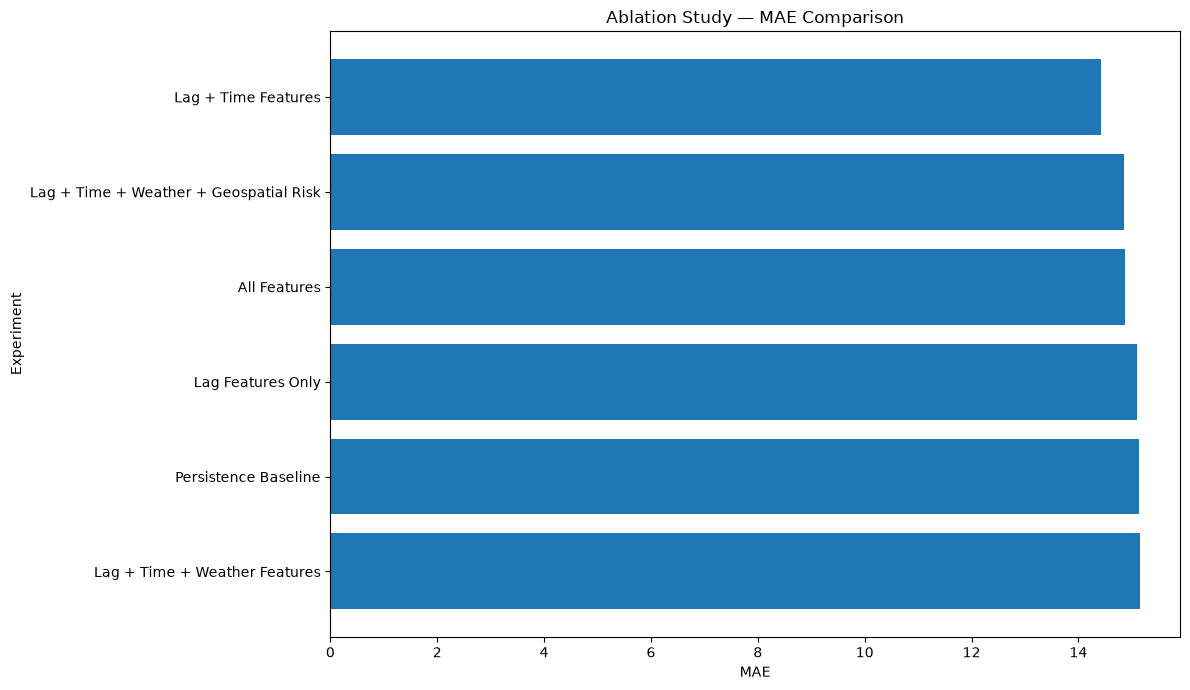

Ablation plot saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\ablation_mae_comparison.png


In [14]:
ABLATION_PLOT_PATH = OUTPUTS_DIR / "ablation_mae_comparison.png"

plot_df = ablation_df_results.sort_values("mae", ascending=True).copy()

plt.figure(figsize=(12, 7))
plt.barh(
    plot_df["experiment"][::-1],
    plot_df["mae"][::-1]
)
plt.xlabel("MAE")
plt.ylabel("Experiment")
plt.title("Ablation Study — MAE Comparison")
plt.tight_layout()
plt.savefig(ABLATION_PLOT_PATH, dpi=200)
plt.show()

print("Ablation plot saved:")
print(ABLATION_PLOT_PATH)

In [15]:
top_feature_importance = feature_importance_df.head(25).copy()

TOP_FEATURES_PATH = OUTPUTS_DIR / "top_25_feature_importance.csv"

top_feature_importance.to_csv(TOP_FEATURES_PATH, index=False)

print("Top 25 feature importance saved:")
print(TOP_FEATURES_PATH)

display(top_feature_importance)

Top 25 feature importance saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_25_feature_importance.csv


,feature,importance
0,aqi,0.404625
1,reported_aqi,0.404121
2,CO,0.040223
3,station_expanding_max_aqi,0.022897
4,aqi_lag_1,0.017086
5,aqi_rolling_mean_3,0.015417
6,station_expanding_min_aqi,0.014619
7,environmental_risk_score,0.003972
8,O3,0.003382
9,NO2,0.002981


In [16]:
hotspot_summary = {
    "total_stations": int(len(station_advanced_df)),
    "total_cities": int(city_advanced_df["city"].nunique()) if "city" in city_advanced_df.columns else None,
    "total_states": int(station_advanced_df["state"].nunique()) if "state" in station_advanced_df.columns else None,
    "current_hotspot_stations": int(station_advanced_df["is_current_hotspot"].sum()) if "is_current_hotspot" in station_advanced_df.columns else None,
    "forecast_hotspot_stations": int(station_advanced_df["is_forecast_hotspot"].sum()) if "is_forecast_hotspot" in station_advanced_df.columns else None,
    "emerging_hotspot_stations": int(station_advanced_df["is_emerging_hotspot"].sum()) if "is_emerging_hotspot" in station_advanced_df.columns else None,
    "top_priority_city": notebook_05_summary.get("top_priority_city"),
    "top_priority_state": notebook_05_summary.get("top_priority_state"),
    "hotspot_distribution": notebook_05_summary.get("hotspot_distribution"),
    "priority_category_distribution": notebook_05_summary.get("priority_category_distribution"),
    "source_distribution": notebook_05_summary.get("source_distribution")
}

HOTSPOT_SUMMARY_PATH = OUTPUTS_DIR / "hotspot_summary.json"

save_json(hotspot_summary, HOTSPOT_SUMMARY_PATH)

print(json.dumps(hotspot_summary, indent=4))

Saved: C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\hotspot_summary.json
{
    "total_stations": 500,
    "total_cities": 264,
    "total_states": 29,
    "current_hotspot_stations": 414,
    "forecast_hotspot_stations": 426,
    "emerging_hotspot_stations": 37,
    "top_priority_city": "Khora",
    "top_priority_state": "Uttar Pradesh",
    "hotspot_distribution": {
        "Critical forecast hotspot": 346,
        "High forecast hotspot": 76,
        "Watchlist": 66,
        "High current hotspot": 5,
        "Critical current hotspot": 4,
        "Emerging hotspot": 3
    },
    "priority_category_distribution": {
        "Moderate": 263,
        "Low": 151,
        "High": 68,
        "Minimal": 18
    },
    "source_distribution": {
        "Biomass / fine-particle combustion": 160,
        "Vehicular traffic": 134,
        "Photochemical smog": 125,
        "Construction / road dust": 46,
        "Insufficient pollutant signal": 18,
        "Industrial combustion": 17
    }
}


In [17]:
final_project_summary = {
    "project_name": "CleanAir AI",
    "run_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "objective": (
        "CleanAir AI is an AQI intelligence platform that fetches real CPCB AQI data, "
        "adds weather and geospatial context, performs pollution source attribution, "
        "forecasts short-term AQI, identifies hotspots, and recommends interventions."
    ),
    "data_sources": {
        "aqi_source": "CPCB/data.gov.in real AQI API",
        "weather_source": "Open-Meteo weather API",
        "satellite_layer": "Proxy aerosol score derived from pollutant and meteorological features"
    },
    "data_coverage": {
        "history_rows": notebook_04_metrics.get("history_rows"),
        "unique_timestamps": notebook_04_metrics.get("unique_timestamps"),
        "unique_stations": notebook_04_metrics.get("unique_stations"),
        "station_rows_advanced_layer": notebook_05_summary.get("station_rows"),
        "city_rows_advanced_layer": notebook_05_summary.get("city_rows"),
        "unique_cities": notebook_05_summary.get("unique_cities"),
        "unique_states": notebook_05_summary.get("unique_states")
    },
    "best_forecasting_model": {
        "model": notebook_04_metrics.get("best_model"),
        "metrics": notebook_04_metrics.get("best_metrics"),
        "category_accuracy": notebook_04_metrics.get("category_accuracy"),
        "high_aqi_f1": notebook_04_metrics.get("high_aqi_f1")
    },
    "advanced_intelligence_outputs": {
        "top_priority_city": notebook_05_summary.get("top_priority_city"),
        "top_priority_state": notebook_05_summary.get("top_priority_state"),
        "hotspot_distribution": notebook_05_summary.get("hotspot_distribution"),
        "priority_category_distribution": notebook_05_summary.get("priority_category_distribution")
    },
    "main_saved_files": {
        "best_model": notebook_04_metrics.get("best_model_file"),
        "model_comparison": notebook_04_metrics.get("model_comparison_file"),
        "feature_importance": notebook_04_metrics.get("feature_importance_file"),
        "station_advanced_intelligence": notebook_05_summary.get("station_advanced_output_file"),
        "city_advanced_intelligence": notebook_05_summary.get("city_advanced_output_file"),
        "interactive_map": notebook_05_summary.get("interactive_map_file"),
        "ablation_results": str(ABLATION_RESULTS_PATH)
    },
    "important_limitation": (
        "The forecasting model was trained on 12 real hourly AQI timestamps. "
        "This is suitable for prototype-level short-term forecasting, but collecting "
        "multiple days or weeks of history would improve robustness."
    )
}

FINAL_PROJECT_SUMMARY_PATH = REPORTS_DIR / "final_project_summary.json"

save_json(final_project_summary, FINAL_PROJECT_SUMMARY_PATH)

print(json.dumps(final_project_summary, indent=4))

Saved: C:\Users\Lenovo\Desktop\CleanAir_AI\reports\final_project_summary.json
{
    "project_name": "CleanAir AI",
    "run_time": "2026-07-16 11:18:26",
    "objective": "CleanAir AI is an AQI intelligence platform that fetches real CPCB AQI data, adds weather and geospatial context, performs pollution source attribution, forecasts short-term AQI, identifies hotspots, and recommends interventions.",
    "data_sources": {
        "aqi_source": "CPCB/data.gov.in real AQI API",
        "weather_source": "Open-Meteo weather API",
        "satellite_layer": "Proxy aerosol score derived from pollutant and meteorological features"
    },
    "data_coverage": {
        "history_rows": 5644,
        "unique_timestamps": 12,
        "unique_stations": 488,
        "station_rows_advanced_layer": 500,
        "city_rows_advanced_layer": 266,
        "unique_cities": 264,
        "unique_states": 29
    },
    "best_forecasting_model": {
        "model": "Random Forest",
        "metrics": {
     

In [19]:
summary_rows = [
    {
        "section": "Project",
        "metric": "Project name",
        "value": "CleanAir AI"
    },
    {
        "section": "Data",
        "metric": "History rows",
        "value": notebook_04_metrics.get("history_rows")
    },
    {
        "section": "Data",
        "metric": "Unique timestamps",
        "value": notebook_04_metrics.get("unique_timestamps")
    },
    {
        "section": "Data",
        "metric": "Unique stations",
        "value": notebook_04_metrics.get("unique_stations")
    },
    {
        "section": "Forecasting",
        "metric": "Best model",
        "value": notebook_04_metrics.get("best_model")
    },
    {
        "section": "Forecasting",
        "metric": "MAE",
        "value": best_metrics.get("mae")
    },
    {
        "section": "Forecasting",
        "metric": "RMSE",
        "value": best_metrics.get("rmse")
    },
    {
        "section": "Forecasting",
        "metric": "R2",
        "value": best_metrics.get("r2")
    },
    {
        "section": "Forecasting",
        "metric": "Category accuracy",
        "value": notebook_04_metrics.get("category_accuracy")
    },
    {
        "section": "Forecasting",
        "metric": "High AQI F1",
        "value": notebook_04_metrics.get("high_aqi_f1")
    },
    {
        "section": "Advanced Intelligence",
        "metric": "Top priority city",
        "value": notebook_05_summary.get("top_priority_city")
    },
    {
        "section": "Advanced Intelligence",
        "metric": "Top priority state",
        "value": notebook_05_summary.get("top_priority_state")
    }
]

final_summary_table = pd.DataFrame(summary_rows)

FINAL_PROJECT_SUMMARY_CSV_PATH = REPORTS_DIR / "final_project_summary.csv"

final_summary_table.to_csv(FINAL_PROJECT_SUMMARY_CSV_PATH, index=False)

print("Final project summary CSV saved:")
print(FINAL_PROJECT_SUMMARY_CSV_PATH)

display(final_summary_table)

Final project summary CSV saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\reports\final_project_summary.csv


,section,metric,value
0,Project,Project name,CleanAir AI
1,Data,History rows,5644
2,Data,Unique timestamps,12
3,Data,Unique stations,488
4,Forecasting,Best model,Random Forest
5,Forecasting,MAE,14.5002
6,Forecasting,RMSE,39.879
7,Forecasting,R2,0.8718
8,Forecasting,Category accuracy,0.8905
9,Forecasting,High AQI F1,0.9776


In [20]:
MODEL_CARD_PATH = DOCS_DIR / "model_card_cleanair_ai.md"

model_card_text = f"""# CleanAir AI — Model Card

## Model Name

CleanAir AI AQI Forecasting Model

## Best Model

{notebook_04_metrics.get("best_model")}

## Purpose

The model predicts the next available AQI timestamp for each monitoring station using recent AQI history, station context, weather features, geospatial proxy features, and source attribution signals.

## Training Data

- Source: CPCB/data.gov.in AQI API
- History rows: {notebook_04_metrics.get("history_rows")}
- Unique timestamps: {notebook_04_metrics.get("unique_timestamps")}
- Unique stations: {notebook_04_metrics.get("unique_stations")}
- Training rows: {notebook_04_metrics.get("train_rows")}
- Test rows: {notebook_04_metrics.get("test_rows")}

## Performance

- MAE: {best_metrics.get("mae")}
- RMSE: {best_metrics.get("rmse")}
- R2: {best_metrics.get("r2")}
- Category accuracy: {notebook_04_metrics.get("category_accuracy")}
- High AQI precision: {notebook_04_metrics.get("high_aqi_precision")}
- High AQI recall: {notebook_04_metrics.get("high_aqi_recall")}
- High AQI F1-score: {notebook_04_metrics.get("high_aqi_f1")}

## Strengths

- Uses real AQI snapshots collected from the live AQI API.
- Compares multiple models instead of relying on a single model.
- Performs strong high-AQI detection.
- Produces uncertainty bounds using residual spread.
- Connects forecasting with hotspot ranking and intervention recommendation.

## Limitations

- Current training history contains only {notebook_04_metrics.get("unique_timestamps")} timestamps.
- Forecasting is suitable for prototype-level short-term AQI prediction.
- More historical data over multiple days or weeks would improve generalization.
- Satellite aerosol score is a proxy, not direct satellite imagery.

## Intended Use

- Short-term AQI forecasting
- Hotspot identification
- City/station prioritization
- Decision-support dashboard
- Prototype-level environmental intelligence system

## Not Intended For

- Legal enforcement without human verification
- Medical diagnosis
- Long-range climate prediction
- Final government policy decision without official validation

## Saved Model File

`{notebook_04_metrics.get("best_model_file")}`
"""

with open(MODEL_CARD_PATH, "w", encoding="utf-8") as file:
    file.write(model_card_text)

print("Model card saved:")
print(MODEL_CARD_PATH)

print(model_card_text)

Model card saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\docs\model_card_cleanair_ai.md
# CleanAir AI — Model Card

## Model Name

CleanAir AI AQI Forecasting Model

## Best Model

Random Forest

## Purpose

The model predicts the next available AQI timestamp for each monitoring station using recent AQI history, station context, weather features, geospatial proxy features, and source attribution signals.

## Training Data

- Source: CPCB/data.gov.in AQI API
- History rows: 5644
- Unique timestamps: 12
- Unique stations: 488
- Training rows: 4124
- Test rows: 1032

## Performance

- MAE: 14.5002
- RMSE: 39.879
- R2: 0.8718
- Category accuracy: 0.8905
- High AQI precision: 0.9634
- High AQI recall: 0.9922
- High AQI F1-score: 0.9776

## Strengths

- Uses real AQI snapshots collected from the live AQI API.
- Compares multiple models instead of relying on a single model.
- Performs strong high-AQI detection.
- Produces uncertainty bounds using residual spread.
- Connects forecasting with hots

In [21]:
data_dictionary_rows = [
    {
        "file": "station_aqi_history.csv",
        "description": "Hourly station-level AQI history collected from CPCB/data.gov.in API."
    },
    {
        "file": "station_source_attributed.csv",
        "description": "Station-level AQI, weather, geospatial proxy, and source attribution features."
    },
    {
        "file": "test_predictions_with_uncertainty.csv",
        "description": "Notebook 04 test predictions with AQI prediction intervals."
    },
    {
        "file": "station_advanced_intelligence.csv",
        "description": "Final station-level advanced intelligence with hotspot, priority, and intervention scores."
    },
    {
        "file": "city_advanced_intelligence_summary.csv",
        "description": "City-level aggregation of advanced AQI intelligence."
    },
    {
        "file": "aqi_model_comparison.csv",
        "description": "Comparison of forecasting models using MAE, RMSE, and R2."
    },
    {
        "file": "feature_importance.csv",
        "description": "Feature importance from the best forecasting model."
    },
    {
        "file": "ablation_results.csv",
        "description": "Ablation study showing performance contribution of feature groups."
    },
    {
        "file": "cleanair_advanced_hotspot_map.html",
        "description": "Interactive station hotspot map."
    },
    {
        "file": "best_aqi_forecast_model.pkl",
        "description": "Saved best AQI forecasting model."
    }
]

data_dictionary_df = pd.DataFrame(data_dictionary_rows)

DATA_DICTIONARY_PATH = DOCS_DIR / "data_dictionary.csv"

data_dictionary_df.to_csv(DATA_DICTIONARY_PATH, index=False)

print("Data dictionary saved:")
print(DATA_DICTIONARY_PATH)

display(data_dictionary_df)

Data dictionary saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\docs\data_dictionary.csv


,file,description
0,station_aqi_history.csv,Hourly station-level AQI history collected fro...
1,station_source_attributed.csv,"Station-level AQI, weather, geospatial proxy, ..."
2,test_predictions_with_uncertainty.csv,Notebook 04 test predictions with AQI predicti...
3,station_advanced_intelligence.csv,Final station-level advanced intelligence with...
4,city_advanced_intelligence_summary.csv,City-level aggregation of advanced AQI intelli...
5,aqi_model_comparison.csv,"Comparison of forecasting models using MAE, RM..."
6,feature_importance.csv,Feature importance from the best forecasting m...
7,ablation_results.csv,Ablation study showing performance contributio...
8,cleanair_advanced_hotspot_map.html,Interactive station hotspot map.
9,best_aqi_forecast_model.pkl,Saved best AQI forecasting model.


In [22]:
deliverable_files = [
    {
        "deliverable": "Notebook 01",
        "path": PROJECT_ROOT / "notebooks" / "01_live_aqi_data_fetching.ipynb"
    },
    {
        "deliverable": "Notebook 02",
        "path": PROJECT_ROOT / "notebooks" / "02_weather_geospatial_integration.ipynb"
    },
    {
        "deliverable": "Notebook 03",
        "path": PROJECT_ROOT / "notebooks" / "03_source_attribution_landuse.ipynb"
    },
    {
        "deliverable": "Notebook 04",
        "path": PROJECT_ROOT / "notebooks" / "04_ml_forecasting_models.ipynb"
    },
    {
        "deliverable": "Notebook 05",
        "path": PROJECT_ROOT / "notebooks" / "05_advanced_intelligence_layers.ipynb"
    },
    {
        "deliverable": "Notebook 06",
        "path": PROJECT_ROOT / "notebooks" / "06_evaluation_ablation_packaging.ipynb"
    },
    {
        "deliverable": "Final project summary JSON",
        "path": FINAL_PROJECT_SUMMARY_PATH
    },
    {
        "deliverable": "Final project summary CSV",
        "path": FINAL_PROJECT_SUMMARY_CSV_PATH
    },
    {
        "deliverable": "Model card",
        "path": MODEL_CARD_PATH
    },
    {
        "deliverable": "Data dictionary",
        "path": DATA_DICTIONARY_PATH
    },
    {
        "deliverable": "Best model",
        "path": Path(notebook_04_metrics.get("best_model_file"))
    },
    {
        "deliverable": "Interactive hotspot map",
        "path": Path(notebook_05_summary.get("interactive_map_file"))
    },
    {
        "deliverable": "Ablation results",
        "path": ABLATION_RESULTS_PATH
    }
]

deliverable_checklist = []

for item in deliverable_files:
    path = item["path"]

    deliverable_checklist.append(
        {
            "deliverable": item["deliverable"],
            "path": str(path),
            "exists": Path(path).exists()
        }
    )

deliverable_checklist_df = pd.DataFrame(deliverable_checklist)

DELIVERABLE_CHECKLIST_PATH = REPORTS_DIR / "final_deliverable_checklist.csv"

deliverable_checklist_df.to_csv(DELIVERABLE_CHECKLIST_PATH, index=False)

print("Final deliverable checklist saved:")
print(DELIVERABLE_CHECKLIST_PATH)

display(deliverable_checklist_df)

Final deliverable checklist saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\reports\final_deliverable_checklist.csv


,deliverable,path,exists
0,Notebook 01,C:\Users\Lenovo\Desktop\CleanAir_AI\notebooks\...,True
1,Notebook 02,C:\Users\Lenovo\Desktop\CleanAir_AI\notebooks\...,True
2,Notebook 03,C:\Users\Lenovo\Desktop\CleanAir_AI\notebooks\...,True
3,Notebook 04,C:\Users\Lenovo\Desktop\CleanAir_AI\notebooks\...,True
4,Notebook 05,C:\Users\Lenovo\Desktop\CleanAir_AI\notebooks\...,True
5,Notebook 06,C:\Users\Lenovo\Desktop\CleanAir_AI\notebooks\...,True
6,Final project summary JSON,C:\Users\Lenovo\Desktop\CleanAir_AI\reports\fi...,True
7,Final project summary CSV,C:\Users\Lenovo\Desktop\CleanAir_AI\reports\fi...,True
8,Model card,C:\Users\Lenovo\Desktop\CleanAir_AI\docs\model...,True
9,Data dictionary,C:\Users\Lenovo\Desktop\CleanAir_AI\docs\data_...,True


In [23]:
missing_deliverables = deliverable_checklist_df[
    deliverable_checklist_df["exists"] == False
]

if len(missing_deliverables) > 0:
    print("Missing deliverables:")
    display(missing_deliverables)

    raise FileNotFoundError("Some final deliverables are missing.")

print("All final deliverables exist.")

All final deliverables exist.


In [24]:
notebook_06_summary = {
    "notebook": "06_evaluation_ablation_packaging.ipynb",
    "run_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "status": "completed",
    "best_model": notebook_04_metrics.get("best_model"),
    "best_model_metrics": notebook_04_metrics.get("best_metrics"),
    "category_accuracy": notebook_04_metrics.get("category_accuracy"),
    "high_aqi_f1": notebook_04_metrics.get("high_aqi_f1"),
    "station_rows": int(len(station_advanced_df)),
    "city_rows": int(len(city_advanced_df)),
    "ablation_results_file": str(ABLATION_RESULTS_PATH),
    "final_project_summary_json": str(FINAL_PROJECT_SUMMARY_PATH),
    "final_project_summary_csv": str(FINAL_PROJECT_SUMMARY_CSV_PATH),
    "model_card": str(MODEL_CARD_PATH),
    "data_dictionary": str(DATA_DICTIONARY_PATH),
    "deliverable_checklist": str(DELIVERABLE_CHECKLIST_PATH),
    "final_model_review": str(FINAL_MODEL_REVIEW_PATH)
}

NOTEBOOK_06_SUMMARY_PATH = REPORTS_DIR / "notebook_06_run_summary.json"

save_json(notebook_06_summary, NOTEBOOK_06_SUMMARY_PATH)

print(json.dumps(notebook_06_summary, indent=4))

Saved: C:\Users\Lenovo\Desktop\CleanAir_AI\reports\notebook_06_run_summary.json
{
    "notebook": "06_evaluation_ablation_packaging.ipynb",
    "run_time": "2026-07-16 11:19:22",
    "status": "completed",
    "best_model": "Random Forest",
    "best_model_metrics": {
        "model": "Random Forest",
        "mae": 14.5002,
        "rmse": 39.879,
        "r2": 0.8718,
        "improvement_over_persistence_percent": 4.22
    },
    "category_accuracy": 0.8905,
    "high_aqi_f1": 0.9776,
    "station_rows": 500,
    "city_rows": 266,
    "ablation_results_file": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\outputs\\ablation_results.csv",
    "final_project_summary_json": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\reports\\final_project_summary.json",
    "final_project_summary_csv": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\reports\\final_project_summary.csv",
    "model_card": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\docs\\model_card_cleanair_ai.md",
    "data_dictionary": "C:\\Users\\Le

In [25]:
print("=" * 70)
print("CleanAir AI final pipeline completed successfully.")
print("=" * 70)

print("\nBest Forecasting Model:")
print(notebook_04_metrics.get("best_model"))

print("\nBest Metrics:")
print(notebook_04_metrics.get("best_metrics"))

print("\nCategory Accuracy:")
print(notebook_04_metrics.get("category_accuracy"))

print("\nHigh AQI F1:")
print(notebook_04_metrics.get("high_aqi_f1"))

print("\nTop Priority City:")
print(notebook_05_summary.get("top_priority_city"), ",", notebook_05_summary.get("top_priority_state"))

print("\nFinal files saved in:")
print("- reports/")
print("- outputs/")
print("- models/")
print("- docs/")

print("\nNotebook 06 completed successfully.")

CleanAir AI final pipeline completed successfully.

Best Forecasting Model:
Random Forest

Best Metrics:
{'model': 'Random Forest', 'mae': 14.5002, 'rmse': 39.879, 'r2': 0.8718, 'improvement_over_persistence_percent': 4.22}

Category Accuracy:
0.8905

High AQI F1:
0.9776

Top Priority City:
Khora , Uttar Pradesh

Final files saved in:
- reports/
- outputs/
- models/
- docs/

Notebook 06 completed successfully.
